<a href="https://colab.research.google.com/github/GaurRitika/P_Folder/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines

Its a part of the logistic regression mainly it improve the idea of logistic regression .

Now there are 2 classifier :

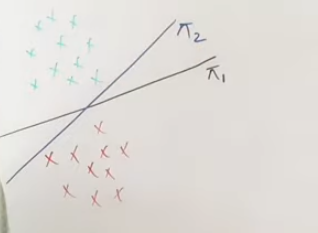

pi1 will be a better classifier because , we always find the nearest distance of the last one for being the safest .

when u pass the wieght in the sigmoid function it calculates the probability . Now , as much the distance is low , more the probability will be close to 0. If any point is close to hyperplane then probablity will be very low.

basically the idea is to maximise the gap or distance such that u can classify the points as widely as possible.

SVM does NOT care about tables.
SVM cares about geometry in high-dimensional space.


##  Support Vectors

Here’s something counter-intuitive:

> **Most data points do NOT matter for SVM.**

Only the **closest points** to the boundary matter.

These points:

* Lie on the margin
* “Support” the hyperplane

They are called:

> **Support Vectors**

If you remove:

* Far-away points → hyperplane doesn’t change
* Support vectors → hyperplane changes completely

Geometrically:

> The entire classifier is defined by a few critical points.

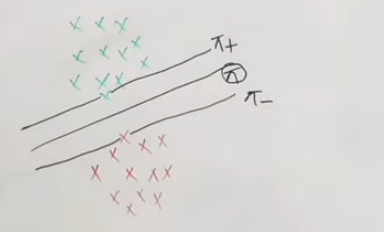

This is one of the most beautiful ideas in ML.

---

##  Compare geometry with Logistic Regression

### Logistic Regression

* Tries to model **P(y|x)**
* Uses **all points**
* Boundary influenced by outliers
* Probabilistic view

### SVM

* Pure **geometric optimization**
* Cares only about **closest points**
* Robust to far-out noise
* No probability (by default)

So geometrically:

> Logistic Regression “averages”
> SVM “defends a border”




















# 1️ From Line → Plane → Hyperplane

## In 2D (a line)

 the equation of a line:

$$
ax + by + c = 0
$$

This divides the 2D plane into two halves.

We can rewrite it as:

$$
w_1 x_1 + w_2 x_2 + b = 0
$$

or in vector form:

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

Where:

$$
\mathbf{w} = (w_1, w_2)
$$

$$
\mathbf{x} = (x_1, x_2)
$$

---

## In 3D (a plane)

In 3D, the equation becomes:

$$
w_1 x_1 + w_2 x_2 + w_3 x_3 + b = 0
$$

This defines a **plane**.

Again, same structure:

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

Where:

$$
\mathbf{w} = (w_1, w_2, w_3)
$$

---

## In N Dimensions

Now generalize.

Let:

$$
\mathbf{x} = (x_1, x_2, \dots, x_n)
$$

$$
\mathbf{w} = (w_1, w_2, \dots, w_n)
$$

Then the hyperplane equation is:

$$
w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = 0
$$

Or compactly:

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

That’s it.

That’s the equation of a hyperplane in R^n.

---

# 2️ What Does This Equation MEAN Geometrically?

---

## 🔹 Key Insight 1: w is NOT just coefficients

The vector w is special.

It is:

> The normal vector to the hyperplane.

That means:

* It is **perpendicular** to the hyperplane.
* It determines the orientation of the plane.

### Why?

Because all points x on the hyperplane satisfy:

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

The dot product measures projection.

Geometrically:

* w.x = projection of x onto w
* The hyperplane contains all points whose projection equals ( -b )

So the plane is defined by:

> All points whose projection onto w is constant.

---

# 3️ Visual Intuition (2D Example)

In 2D, suppose:

$$
\mathbf{w} = (2, 1)
$$

The hyperplane:

$$
2x_1 + x_2 + b = 0
$$

The line is perpendicular to ( (2,1) ).


![Image](https://images.nagwa.com/figures/explainers/939127418581/1.svg)
![Image](https://i.sstatic.net/IJRXK.png)

Notice:

* The arrow (w) sticks out perpendicular.
* The boundary rotates when w changes.
* The boundary shifts when b changes.

---

# 4️ Role of ( b ) (Bias Term)

The term ( b ) shifts the hyperplane.

If:

$$
\mathbf{w} \cdot \mathbf{x} = 0
$$

The hyperplane passes through the origin.

If:

$$
\mathbf{w} \cdot \mathbf{x} + b = 0
$$

Then it is shifted.

Geometrically:

* w controls rotation
* ( b ) controls translation

---

# 5️ How Does It Separate Space?

Take any point x.

Compute:

$$
f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b
$$

Three possibilities:

* f(x) > 0  → one side
* f(x) < 0  → other side
* f(x) = 0 → exactly on boundary

So the hyperplane divides space into two half-spaces.

Classification becomes:

$$
\text{sign}(\mathbf{w} \cdot \mathbf{x} + b)
$$

That’s linear classification.

---

# 6️ Distance from a Point to a Hyperplane

The perpendicular distance of a point x0 from the hyperplane:

$$
\text{Distance} =
\frac{\left| \mathbf{w} \cdot \mathbf{x}_0 + b \right|}{| \mathbf{w} |}
$$

Notice:

* Numerator = signed output
* Denominator = magnitude of ( \mathbf{w} )

So:

$$
\frac{\mathbf{w} \cdot \mathbf{x} + b}{| \mathbf{w} |}
$$

is the **signed geometric distance**.

---

# 7️ Why ||w|| Matters

If we multiply the entire equation by 100:

$$
100\mathbf{w} \cdot \mathbf{x} + 100b = 0
$$

It represents the **same hyperplane**.

So:

* The direction of w matters
* The magnitude of w changes scaling

But the distance formula divides by ||w||.

This is why:

$$
\text{Margin} = \frac{2}{| \mathbf{w} |}
$$

So minimizing ||w|| increases margin.

This is the geometric heart of SVM optimization.



# 1. Problem Setup (Linearly Separable Case)

We assume:

* Binary classification
* Linearly separable data

Dataset:

$$
{(x_i, y_i)}_{i=1}^{m}
$$

Where:

$$
x_i \in \mathbb{R}^n
$$

$$
y_i \in {-1, +1}
$$

**Important:**
SVM uses labels ( {-1, +1} ), not ( {0,1} ).
This makes the math cleaner.

---

# 2. Equation of the Hyperplane

The separating hyperplane:

$$
w^T x + b = 0
$$

Where:

$$
w \in \mathbb{R}^n, \quad b \in \mathbb{R}
$$

Classification rule:

$$
\hat{y} = \text{sign}(w^T x + b)
$$

---

# 3. Condition for Correct Classification

If a point is correctly classified:

For ( y_i = +1 ):

$$
w^T x_i + b > 0
$$

For ( y_i = -1 ):

$$
w^T x_i + b < 0
$$

We combine both into one condition:

$$
y_i (w^T x_i + b) > 0
$$

That ensures correct classification.

---

# 4. Introducing the Margin

Now comes the key idea.

We don’t just want correct classification.

We want **maximum margin**.

---

## 4.1 Functional Margin

Define:

$$
\gamma_i = y_i (w^T x_i + b)
$$

This is called the **functional margin**.

For correct classification:

$$
\gamma_i > 0
$$

The margin of the whole dataset:

$$
\gamma = \min_i \gamma_i
$$

---

## Important Problem (Scaling Issue)

If we multiply ( w ) and ( b ) by 100:

$$
(100w)^T x + 100b = 0
$$

The hyperplane stays the same.

But:

$$
\gamma_i
$$

also multiplies by 100.

So functional margin depends on scaling.

This is bad.

We need a scale-independent margin.

---

# 5. Fixing the Scale

To remove scaling ambiguity, we enforce:

$$
y_i (w^T x_i + b) \geq 1
$$

This means:

The closest points satisfy:

$$
y_i (w^T x_i + b) = 1
$$

These are the **support vectors**.

Now scaling is fixed.

---

# 6. Geometric Margin

Distance of a point from hyperplane:

$$
\frac{|w^T x_i + b|}{|w|}
$$

So geometric margin becomes:

$$
\frac{y_i (w^T x_i + b)}{|w|}
$$

Since we enforced:

$$
y_i (w^T x_i + b) \geq 1
$$

The minimum geometric margin is:

$$
\frac{1}{|w|}
$$

Total margin (distance between two margin planes):

$$
\frac{2}{|w|}
$$

---

# 7. Objective of Hard Margin SVM

We want to maximize margin:

$$
\frac{2}{|w|}
$$

Equivalent to minimizing:

$$
|w|
$$

For mathematical convenience, we minimize:

$$
\frac{1}{2} |w|^2
$$

Why squared?

* Differentiable
* Convex
* Easier optimization

---

# 8. Final Optimization Problem (Primal Form)

Hard Margin SVM:

$$
\min_{w,b} \quad \frac{1}{2} |w|^2
$$

Subject to:

$$
y_i (w^T x_i + b) \geq 1
\quad \text{for all } i = 1,2,\dots,m
$$

This is a:

* Convex optimization problem
* Quadratic objective
* Linear constraints

This is called a **Quadratic Programming (QP)** problem.

---

# 9. Why This Works (Deep Understanding)

We are:

* Minimizing ( |w|^2 )
* While forcing every point to stay outside the margin

Geometrically:

* Smaller ( |w| ) → wider margin
* Constraints → no point enters margin

This guarantees:

* Maximum separation
* Best generalization (for separable data)

---

# 10. Key Observations

1. This only works if data is perfectly separable.
2. If even one point violates constraint → no solution.
3. Only points satisfying:

$$
y_i (w^T x_i + b) = 1
$$

matter in final solution.

Those are the **support vectors**.

---

# 11. Why It’s Convex (Very Important)

Objective:

$$
\frac{1}{2} |w|^2
$$

is convex (quadratic positive definite).

Constraints:

$$
y_i (w^T x_i + b) \geq 1
$$

are linear.

Convex objective + linear constraints
→ Unique global minimum.

No local minima problem.

---

# 12. What We Have Built

We started from:

* Geometry
* Distance formula
* Margin definition
* Scaling issue
* Fixed scaling
* Derived optimization problem

Without magic.

This is **Hard Margin SVM**.


Let's take a dataset :)

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

## Working with perfectly Linear Dataset

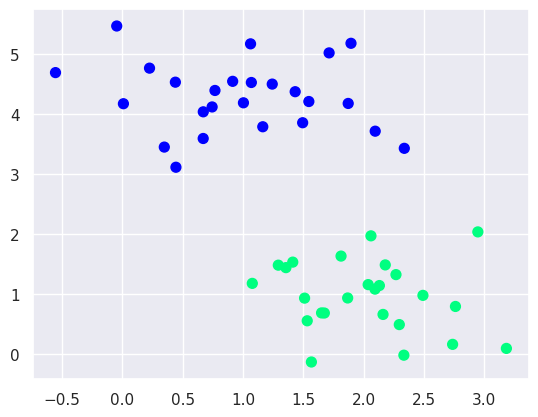

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples = 50, centers = 2, random_state = 0, cluster_std = 0.60)
plt.scatter(  X[:, 0], X[:, 1], c = y, s = 50, cmap = 'winter');

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel = 'linear', C = 1) #object creation
model.fit(X, y)
# now we trained the model on x , y (above dataset)

SVC(C=1, kernel='linear')

In [ ]:
#let's make a function that will find the best fit line.

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

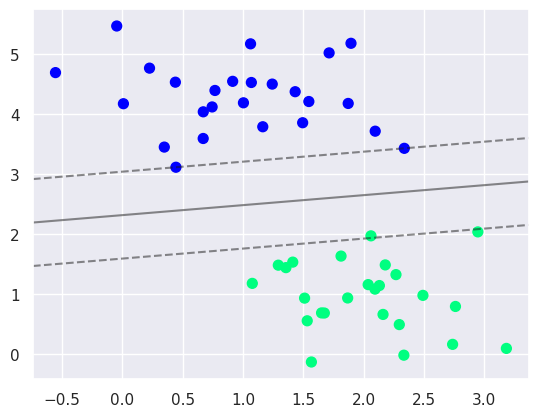

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model);

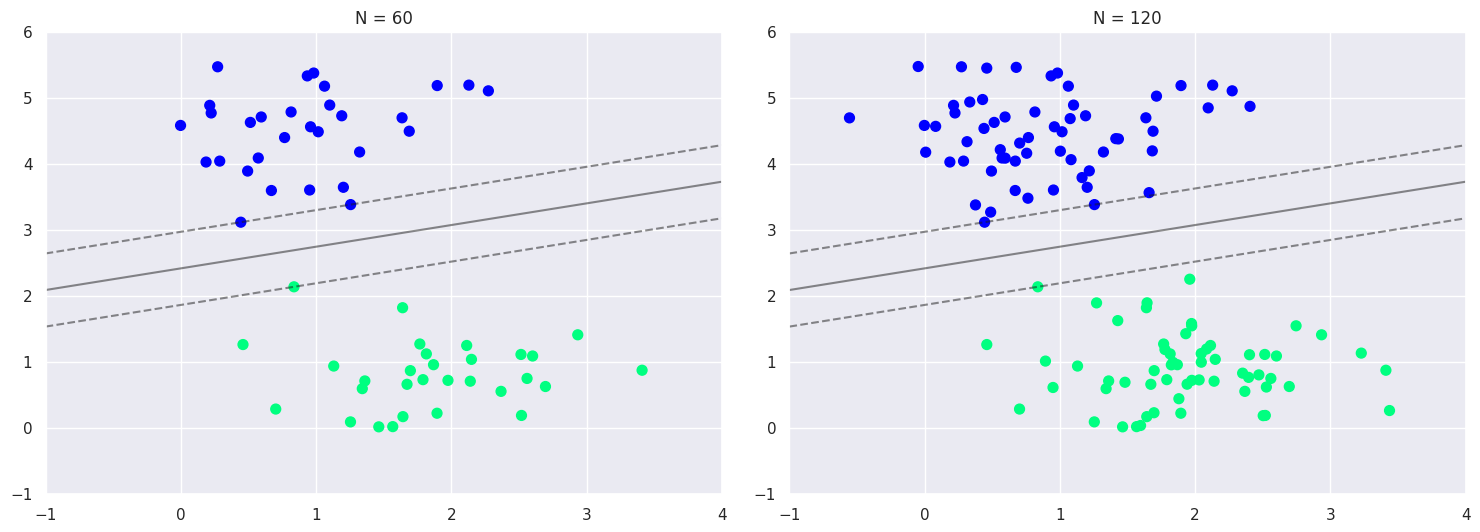

In [ ]:
#if we increase the samples size , svm is insensitive to this
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

## Working with almost linearly seperable dataset

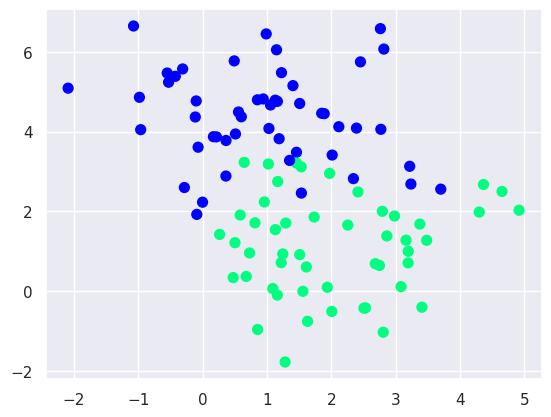

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

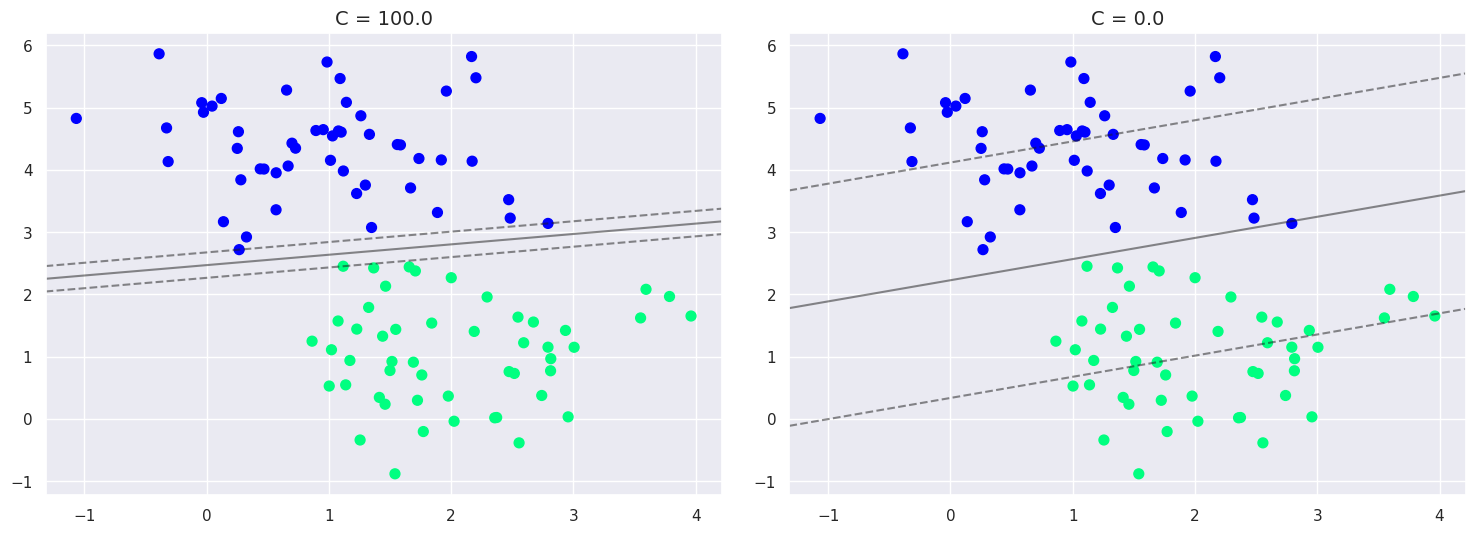

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

# Soft Margin SVM

Soft Margin SVM is where SVM becomes practical.

Hard margin was beautiful, but unrealistic.

Soft margin is where geometry + optimization + robustness meet.

# 1. Why Hard Margin Fails

Hard margin requires:

$$
y_i (w^T x_i + b) \geq 1 \quad \forall i
$$

This assumes:

* Perfectly separable data
* No noise
* No overlap

In real-world data:

* Outliers exist
* Classes overlap
* Measurement noise exists

Even **one bad point** makes hard margin infeasible.

So we relax the constraints.

---

# 2. Introducing Slack Variables

We introduce slack variables:

$$
\xi_i \geq 0
$$

These measure **violation of the margin constraint**.

Now constraint becomes:

$$
y_i (w^T x_i + b) \geq 1 - \xi_i
$$

---

# 3. What Does ξi Mean Geometrically?

There are 3 cases.

---

### Case 1: Correct and Outside Margin

If:

$$
\xi_i = 0
$$

Then:

$$
y_i (w^T x_i + b) \geq 1
$$

Point is correctly classified and outside margin.

---

### Case 2: Inside Margin but Correct Side

If:

$$
0 < \xi_i < 1
$$

Then:

$$
0 < y_i (w^T x_i + b) < 1
$$

Point is correctly classified but inside the margin.

---

### Case 3: Misclassified

If:

$$
\xi_i > 1
$$

Then:

$$
y_i (w^T x_i + b) < 0
$$

Point is misclassified.

---

So slack variable measures:

$$
\xi_i = \max(0, 1 - y_i (w^T x_i + b))
$$

This expression becomes hinge loss.

---

# 4. New Objective Function

We want:

* Large margin → minimize ( |w|^2 )
* Small violations → minimize ξi

So we combine both:

$$
\min_{w,b,\xi}
\quad
\frac{1}{2} |w|^2
+
C \sum_{i=1}^{m} \xi_i
$$

Subject to:

$$
y_i (w^T x_i + b) \geq 1 - \xi_i
$$

$$
\xi_i \geq 0
$$

---

# 5. Meaning of ( C )

This is extremely important.

( C ) controls the trade-off:

$$
\frac{1}{2} |w|^2
\quad \text{vs} \quad
\sum \xi_i
$$

---

### If C→∞

* Violations heavily penalized
* Model tries to avoid misclassification
* Behaves like hard margin (if possible)
* Low bias, high variance

---

### If C→0

* Violations less important
* Larger margin allowed
* More misclassification tolerated
* High bias, low variance

So:

$$
C = \text{Regularization parameter}
$$

Geometrically:

> ( C ) controls how much we care about points inside the margin.

---

# 6. Geometric Interpretation of Soft Margin

Hard margin:

Two rigid walls at:

$$
w^T x + b = 1
$$

$$
w^T x + b = -1
$$

No one allowed inside.

Soft margin:

Walls still exist.

But points are allowed:

* Inside margin
* On wrong side
* Even misclassified

But they pay penalty.

Instead of perfect separation, we allow controlled violations.

---

# 7. Soft Margin as Loss Minimization

Recall:

$$
\xi_i = \max(0, 1 - y_i (w^T x_i + b))
$$

Substitute into objective:

$$
\min_{w,b}
\quad
\frac{1}{2} |w|^2
+
C \sum_{i=1}^{m}
\max(0, 1 - y_i (w^T x_i + b))
$$

The term:

$$
\max(0, 1 - y_i (w^T x_i + b))
$$

is called **hinge loss**.

So SVM is equivalent to:

$$
\min_{w,b}
\quad
\frac{1}{2} |w|^2
+
C \sum_{i=1}^{m}
L_{\text{hinge}}(y_i, f(x_i))
$$

Where:

$$
L_{\text{hinge}} = \max(0, 1 - y f(x))
$$

---

# 8. Compare with Logistic Regression

Logistic regression minimizes:

$$
\sum_{i=1}^{m}
\log\left(1 + e^{-y_i (w^T x_i + b)}\right)
$$

SVM minimizes:

$$
\sum_{i=1}^{m}
\max(0, 1 - y_i (w^T x_i + b))
$$

Difference:

* Logistic → smooth, probabilistic
* SVM → piecewise linear, margin-focused

If:

$$
y_i (w^T x_i + b) \geq 1
$$

Then hinge loss = 0.

Logistic still keeps updating those points.

That’s why SVM depends mainly on support vectors.

---

# 9. Final Soft Margin Primal Form

$$
\boxed{
\min_{w,b,\xi}
\quad
\frac{1}{2} |w|^2
+
C \sum_{i=1}^{m} \xi_i
}
$$

Subject to:

$$
y_i (w^T x_i + b) \geq 1 - \xi_i
$$

$$
\xi_i \geq 0
$$

This is convex optimization.

Global minimum guaranteed.
